# Light Curve of a Star: Pi Mensae

## Requisite modules and data

In [207]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

search_result = lk.search_lightcurve("Pi Mensae", mission="TESS")
lc = search_result.download()

print(lc)

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2969604950604  1.4641956e+06 ...  9.0913408e-02 -7.2966635e-02
1325.2983493645327  1.4643365e+06 ...  6.2022530e-02 -1.0871942e-01
 1325.299738234005  1.4643485e+06 ...  6.1673984e-02 -1.1394957e-01
 1325.301127103477  1.4643674e+06 ...  6.0909923e-02 -1.2573890e-01
1325.3025159730657  1.4642560e+06 ...  5.3837594e-02 -1.2532526e-01
 1325.303904842538  1.4644681e+06 ...  5.2977830e-02 -1.2562653e-01
1325.3052937121265  1.4643586e+06 ...  5.7222184e-02 -1.3051888e-01
1325.3066825815986  1.4643564e+06 ...  5.5443291e-02 -1.2712292e-01
1325.3080714511873  1.4645452e+06 ...  5.1877767e-02 -1.2947108e-01
               ...            ... ...            ...            ...
1353.1645661947705  1.4646795e+06 ...  5.5579260e-02 -1.1038263e-02
1353.1659550506233  1.4649392e+06 ...  6.0031198

c:\Users\HR1000TU\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 108 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


## Information on observation times

In [208]:
obs_time = lc.time      # list of observation times

# some info on oservation times
num_observations = len(obs_time)
start_time = obs_time[0]
end_time = obs_time[-1]
total_duration = end_time - start_time

print(f"Number of observations: {num_observations}")
print(f"Start time: {start_time} days (BTJD)")
print(f"End time: {end_time} days (BTJD)")
print(f"Total duration: {total_duration} days")

Number of observations: 18264
Start time: 1325.2969604950604 days (BTJD)
End time: 1353.1770658972157 days (BTJD)
Total duration: 27.880105402155323 days


## Data cleaning and statistical properties

In [209]:
# Removing NaNs and statistical outliers from the data
lc_clean = lc.remove_nans().remove_outliers()

flux = lc_clean.flux

# Stats of the flux values
min_flux = np.min(flux)
max_flux = np.max(flux)
mean_flux = np.mean(flux)
median_flux = np.median(flux)
flux_std = np.std(flux)

print(f"Minimum flux: {min_flux}")
print(f"Maximum flux: {max_flux}")
print(f"Mean flux: {mean_flux}")
print(f"Median flux: {median_flux}")
print(f"Standard deviation of flux: {flux_std}")

Minimum flux: 1463661.625 electron / s
Maximum flux: 1465526.125 electron / s
Mean flux: 1464594.625 electron / s
Median flux: 1464602.375 electron / s
Standard deviation of flux: 195.93414306640625 electron / s


## Visualisations of the lightcurve

### Raw light curve

<Axes: title={'center': 'Raw Light Curve: Pi Mensae'}, xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

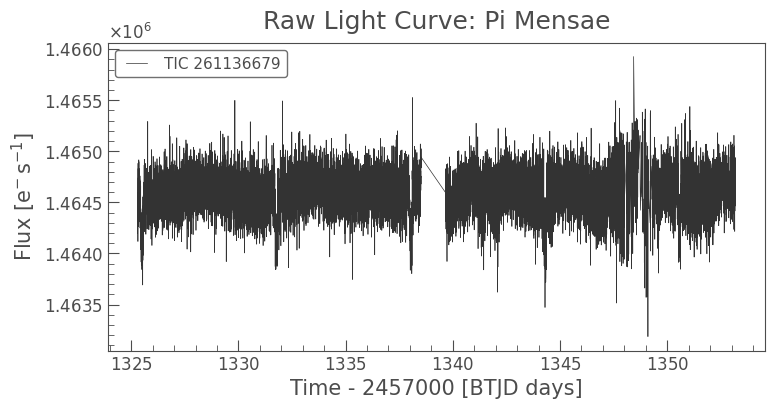

In [210]:
%matplotlib inline
# raw light curve
lc.plot(title='Raw Light Curve: Pi Mensae')

### Cleaned light curve

<Axes: title={'center': 'Cleaned Light Curve: Pi Mensae'}, xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

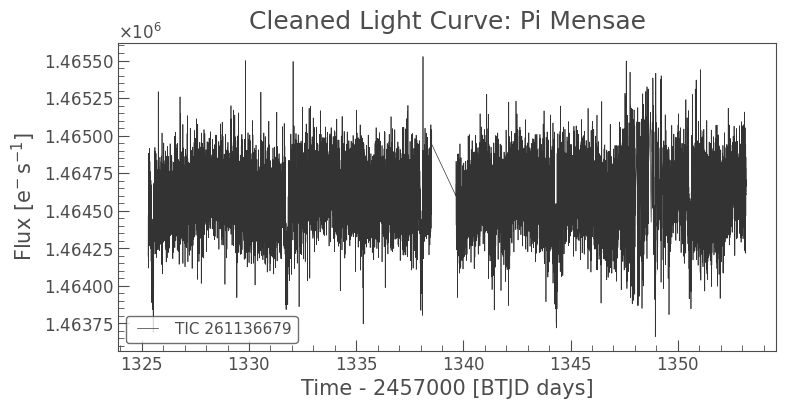

In [211]:
%matplotlib inline
# cleaned light curve
lc_clean.plot(title='Cleaned Light Curve: Pi Mensae')

The cleaned version has a smaller range of values as compared to the raw light curve and has a lesser number of extreme spikes. This is because the statistical outliers of the data have been removed.

### Histogram of flux values

Text(0.5, 0, 'Flux ($e^-s^{-1}$)')

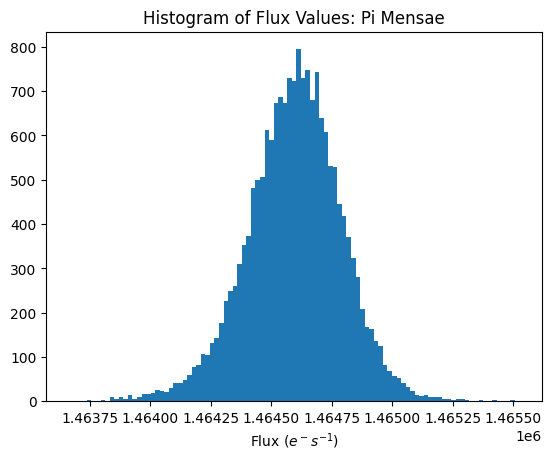

In [212]:
plt.hist(np.array(flux.value), bins='auto');
plt.title('Histogram of Flux Values: Pi Mensae')
plt.xlabel('Flux ($e^-s^{-1}$)')

## Some questions


1. What does the x-axis represent?<br>
For the light curves, the x-axis is the time of observation measured in BTJD days or Barycentric TESS Julian Date. BJD is the time of observation after correcting for the time difference due to the motion of the Earth around the Sun (the time in the frame of the center of mass of the solar   system - the barycenter). BTJD is BJD offset by a constant for convinience. It is used by the TESS satellite for timekeeping.<br><br>

2. What does the y-axis represent?<br>
The y-axis represents the flux of incoming star light measured in electrons per second (x10<sup>6</sup>). The light is measured by a Charge-Coupled Device (CCD) which measures the charge created by the incoming light exciting some electrons. The unit is a direct reflection of this measurement.<br><br>

3. Why are NaN values removed?<br>
NaN (Not A Number) values can end up in a lightcurve, or any data set, for a number of reasons. For example - missing data, instrumental defects, failure in download, or mathematical problems(like division by zero) during processing. These, for the most part, are unphysical and do not represent any actual data. Hence they are removed or else they might cause problems down the line.<br><br>

4. Why are outliers removed?<br>
Statistical outliers are values in the data which are way above/below the everything else, seemingly for no reason. They can be caused by instrument failure or calculation errors but could also be actual data. Regardless, for the purposes of calculating certain statistical properties, such as the mean or the standard deviation, they should be removed as they can severely bias their values.<br><br>

5. What would an exoplanet transit look like in a light curve?<br>
The transit of an exoplanet would look like a sharp dip in the brightness of the star as the planet comes in between the star and the telesope and a reversion to normal light levels as the planet moves away from our line of sight. This would occur periodically as the planet keeps orbiting the star. The depth the dip can indicate the size of the planet in relation to the star, the duration of the dip can tell us the size of the star and the frequency transits can the let us know the period of revolution of the planet around the star.<br><br>

6. Why can noisy data make transit detection difficult?<br>
Transits are infrequent and sometimes can be very short. If the noise in the data is too much, the size or duration of the transit may be thrown off or one may not show up at all. Even confirming the existance of an exoplanet requires significant regularity in the data and calculations. So noisy data can complicate the detection of transits and, by extension, detection of exoplanets.